***Churn Vs Non Churn***


*Import Necessary Libraries*

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import warnings
print("All Labraries are imported successfully")


All Labraries are imported successfully


In [79]:
from sklearn.preprocessing import LabelEncoder, StandardScaler



*Data set Loading*

In [80]:
df = pd.read_csv("telecome.csv")
print("Data is loaded successfully")

Data is loaded successfully


In [81]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


*Dataset Preprocessing & EDA*

In [82]:
print("\nData info:")
print(df.info())


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

In [83]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [84]:
print("\nTarget variable distribution:")
print(df['Churn'].value_counts(normalize=True))


Target variable distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [85]:
df=df.drop('customerID' ,axis=1)

In [86]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [87]:
Le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = Le.fit_transform(df[col])

In [88]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [89]:
X = df[['SeniorCitizen','Partner','Dependents','tenure','OnlineSecurity','OnlineBackup','DeviceProtection',
        'TechSupport','PaymentMethod','PaperlessBilling','MonthlyCharges','TotalCharges']]
y = df['Churn']

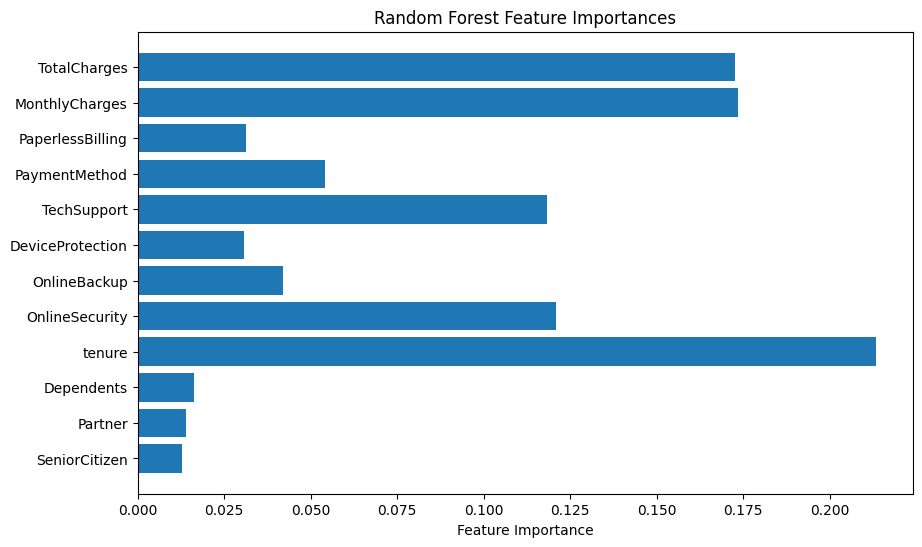

In [90]:
# Plot feature importances from the best_model
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.show()

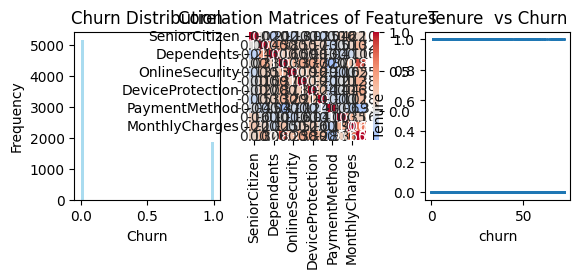

In [91]:
plt.Figure(figsize=(15 , 10))
plt.subplot(2, 3,1)
plt.hist(y ,bins=50 , alpha=0.7,color= 'skyblue')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Frequency")
# Corealtion Matrix
plt.subplot(3, 3, 2)
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix , annot= True , cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corelation Matrices of Features")

plt.subplot(2, 3, 3)
plt.scatter(X['tenure'], y, alpha=0.5, s=1)
plt.title("Tenure  vs Churn")
plt.xlabel("churn")
plt.ylabel("Tenure")
plt.show()

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
# Scale numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

*Model Trainning*

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [95]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [103]:
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1] 

In [104]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Accuracy score
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[945  91]
 [205 168]]

Accuracy Score: 0.7899219304471257


*Hyperparameter Tunning*

In [107]:
import sklearn.model_selection as GridSearchCV

In [100]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [{0:1,1:1}, {0:1,1:2}, {0:1,1:3}]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2},
                                          {0: 1, 1: 3}],
                         'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall')

In [101]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'class_weight': {0: 1, 1: 3}, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [105]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [106]:
print("\n✅ Test Set Accuracy (Selected Features):", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report (Selected Features):\n", classification_report(y_test, y_pred))
print("\n📉 Confusion Matrix (Selected Features):\n", confusion_matrix(y_test, y_pred))



✅ Test Set Accuracy (Selected Features): 0.7679205110007097

📊 Classification Report (Selected Features):
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.55      0.73      0.62       373

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


📉 Confusion Matrix (Selected Features):
 [[811 225]
 [102 271]]


*Confusion Matrix*

Text(0.5, 1.0, 'Confusion Matrix Heatmap')

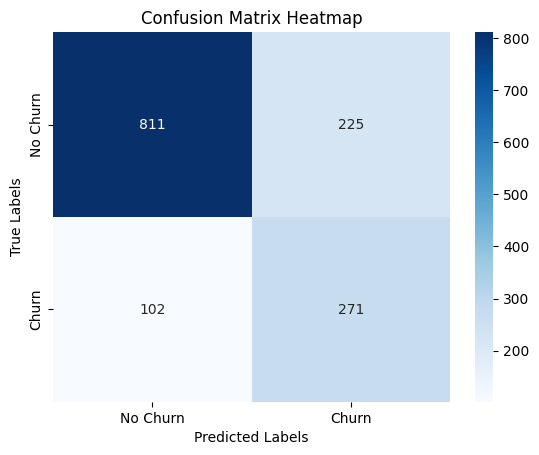

In [109]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

# Plot heatmap
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=ax)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')


In [110]:
accuracy = 0.7679205110007097
precision_churn = 0.55
recall_churn = 0.73
f1_churn = 0.62
cm = [[811, 225], [102, 271]]

**Model Summary**

In [111]:
# Print performance summary
print("📊 Model Performance Summary (Random Forest)\n")
print(f"✅ Accuracy: {accuracy:.2%}")
print(f"🎯 Precision (Churn): {precision_churn:.2f}")
print(f"🔁 Recall (Churn): {recall_churn:.2f}")
print(f"⚖️ F1 Score (Churn): {f1_churn:.2f}\n")

📊 Model Performance Summary (Random Forest)

✅ Accuracy: 76.79%
🎯 Precision (Churn): 0.55
🔁 Recall (Churn): 0.73
⚖️ F1 Score (Churn): 0.62



**Saving the model**

In [116]:
import pickle
# save the training model use pickle
model_filename = "model.pkl"
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Model save to {model_filename}")

Model save to model.pkl


In [118]:

scaler_filename = "scaler.pkl"
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"Scaler saved in {scaler_filename}")


Scaler saved in scaler.pkl


In [122]:
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [119]:
#verify that we can model back
print("\nVerifying saved file")
with open(model_filename , 'rb') as file:
    loaded_model =  pickle.load(file)

with open(scaler_filename , 'rb') as file:
    loaded_scaler = pickle.load(file)
print("Model and scaler are loaded for verification")


Verifying saved file
Model and scaler are loaded for verification


In [121]:
#Test the loaded with sample prediction
sample_prediction = loaded_model.predict(X_test[:1])
print(f"\nSample prediction with loaded mode : {sample_prediction[0]}")


Sample prediction with loaded mode : 1
